<a href="https://colab.research.google.com/github/RomanBr89/HW2/blob/main/HW%202%20%D0%B1%D0%B5%D0%B7%20%D1%80%D0%B0%D0%B7%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%BD%D0%B0%20%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# data_load
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor



file_path = 'smmhdataset.csv'
def load_csv(file_path):

    try:
        df = pd.read_csv(file_path)
        print(f'Файл успешно загружен')
        return df
    except Exception as e:
        print(f'Ошибка при загрузке CSV: {e}')
        return None

df = load_csv(file_path)


df.head(5)
#Узнаем как часто люди испытывают проблемы со сном из-за соц сетей

time_spend = '8. What is the average time you spend on social media every day?'
sleep_problem = '20. On a scale of 1 to 5, how often do you face issues regarding sleep?'


Файл успешно загружен


count                   481
unique                    6
top       More than 5 hours
freq                    116
Name: 8. What is the average time you spend on social media every day?, dtype: object
8. What is the average time you spend on social media every day?
More than 5 hours        116
Between 2 and 3 hours    101
Between 3 and 4 hours     93
Between 1 and 2 hours     70
Between 4 and 5 hours     67
Less than an Hour         34
Name: count, dtype: int64


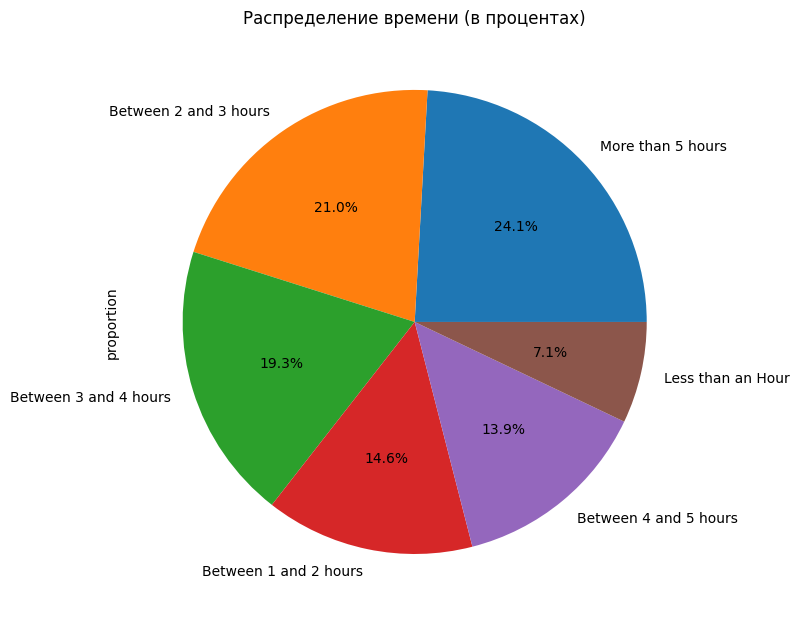

In [4]:
#data_proc
#Потраченное время в соц сетях
print(df[time_spend].describe())

print(df[time_spend].value_counts())

percentages = df[time_spend].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 8))
percentages.plot(
    kind='pie',
    labels=percentages.index,
    autopct='%.1f%%',
)

plt.title('Распределение времени (в процентах)')
plt.tight_layout()
plt.show()



In [5]:
#Проверка на пропущенные значения
df[time_spend].isnull().sum()

np.int64(0)

count    481.000000
mean       3.201663
std        1.461619
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max        5.000000
Name: 20. On a scale of 1 to 5, how often do you face issues regarding sleep?, dtype: float64
20. On a scale of 1 to 5, how often do you face issues regarding sleep?
5    125
4    110
2     91
1     86
3     69
Name: count, dtype: int64


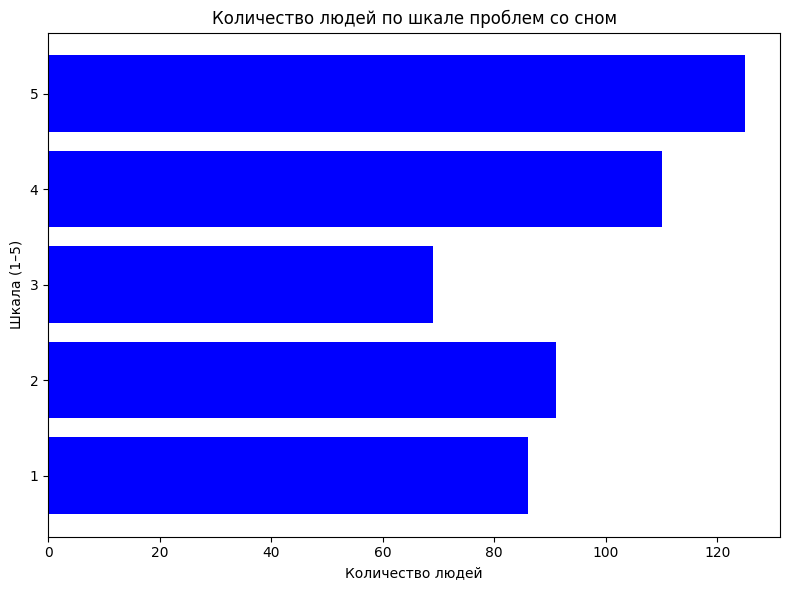

In [6]:
# Количество человек испытвающих проблемы со сном по шкале от 1 до 5, где 5 - есть проблемы со сном, 1 - проблем нет

print(df[sleep_problem].describe())
print(df[sleep_problem].value_counts())

counts = df[sleep_problem].value_counts().sort_index()  # сортировка по шкале 1–5

# Построение горизонтальной диаграммы
plt.figure(figsize=(8, 6))
plt.barh(counts.index, counts.values, color='blue')
plt.xlabel('Количество людей')
plt.ylabel('Шкала (1–5)')
plt.title('Количество людей по шкале проблем со сном')
plt.tight_layout()
plt.show()

In [7]:
df[sleep_problem].isnull().sum()

np.int64(0)

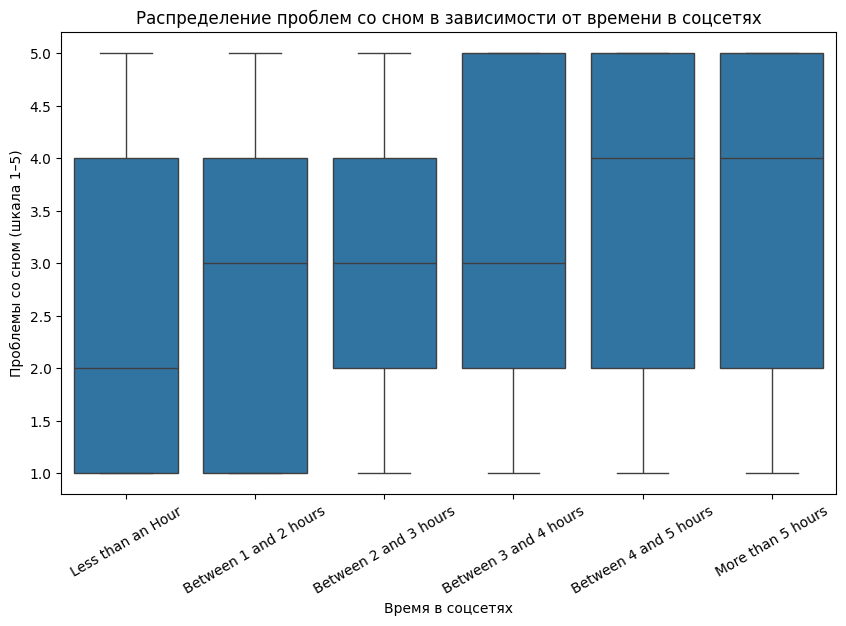

In [10]:
# Смотрим как меняются ответы о проблемах со сном в зависимости от проведенного времени

time_order = {
    'Less than an Hour': 0,
    'Between 1 and 2 hours': 1,
    'Between 2 and 3 hours': 2,
    'Between 3 and 4 hours': 3,
    'Between 4 and 5 hours': 4,
    'More than 5 hours': 5
}

df['time_numeric'] = df[time_spend].map(time_order)

plt.figure(figsize=(10,6))
sns.boxplot(x=df[time_spend], y=df[sleep_problem], order=time_order.keys())
plt.xlabel('Время в соцсетях')
plt.ylabel('Проблемы со сном (шкала 1–5)')
plt.title('Распределение проблем со сном в зависимости от времени в соцсетях')
plt.xticks(rotation=30)
plt.show()

MSE: 2.1967476390434877
R2: -0.014787830703072435


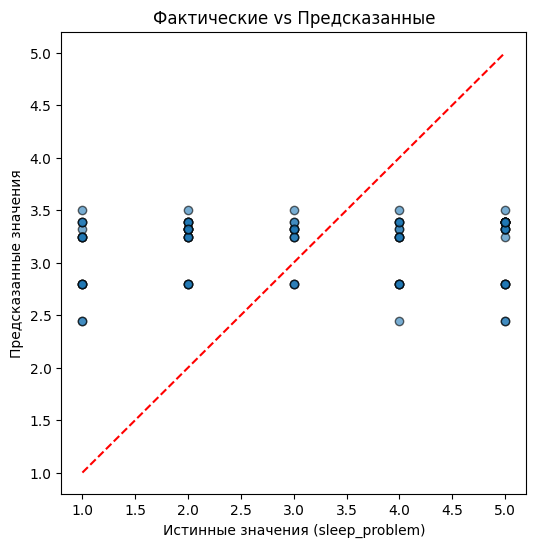

In [23]:
# data_train, data_predict

# Используем регрессор дерева для обучения модели
X = df[['time_numeric']]
y = df[sleep_problem]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
plt.plot([1, 5], [1, 5], 'r--')

plt.xlabel('Истинные значения (sleep_problem)')
plt.ylabel('Предсказанные значения')
plt.title('Фактические vs Предсказанные')
plt.show()

Из чего мы видим, что все плохо. Мало признаков для корректного обучения модели.


